In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/processed/cleaned_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df.shape)
df.head()

(805549, 13)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,DayOfWeek,Hour,IsWeekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,December,Tuesday,7,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,December,Tuesday,7,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,December,Tuesday,7,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,December,Tuesday,7,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,December,Tuesday,7,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805549 entries, 0 to 805548
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  int64         
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[ns]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  object        
 8   Revenue      805549 non-null  float64       
 9   Month        805549 non-null  object        
 10  DayOfWeek    805549 non-null  object        
 11  Hour         805549 non-null  int64         
 12  IsWeekend    805549 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(4), object(5)
memory usage: 79.9+ MB


In [5]:
df.describe()

,Invoice,Quantity,InvoiceDate,Price,Customer ID,Revenue,Hour,IsWeekend
count,805549.000000,805549.000000,805549,805549.000000,805549.000000,805549.000000,805549.000000,805549.000000
mean,537410.713358,13.290522,2011-01-02 10:24:44.106814464,3.206561,15331.954970,22.026505,12.801966,0.169734
min,489434.000000,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000,6.000000,0.000000
25%,514962.000000,2.000000,2010-07-07 12:08:00,1.250000,13982.000000,4.950000,11.000000,0.000000
50%,536989.000000,5.000000,2010-12-03 15:10:00,1.950000,15271.000000,11.850000,13.000000,0.000000
75%,561617.000000,12.000000,2011-07-28 13:05:00,3.750000,16805.000000,19.500000,14.000000,0.000000
max,581587.000000,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000,20.000000,1.000000
std,26666.068909,143.634088,NaN,29.199173,1696.737039,224.041928,2.290110,0.375399


In [6]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
Month          0
DayOfWeek      0
Hour           0
IsWeekend      0
dtype: int64

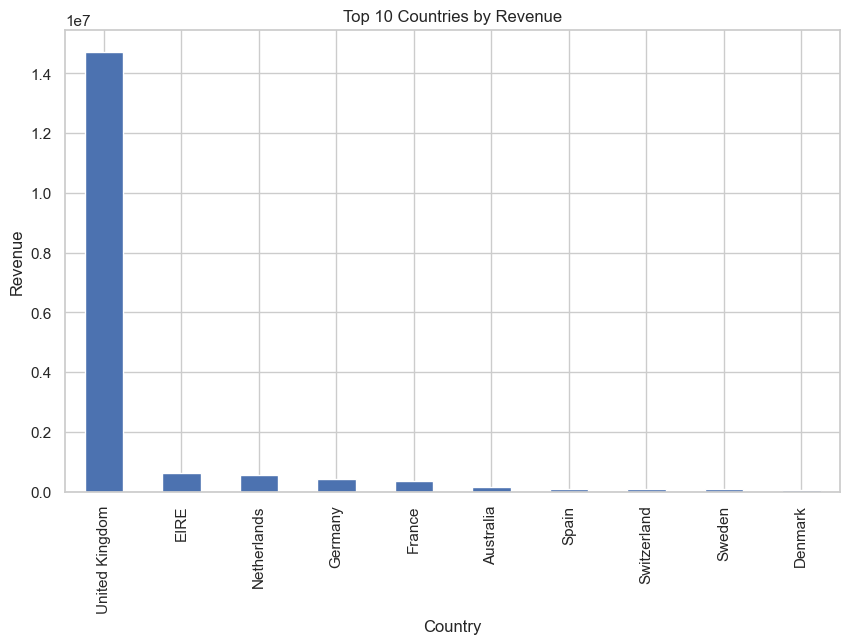

In [7]:
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

country_sales.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()

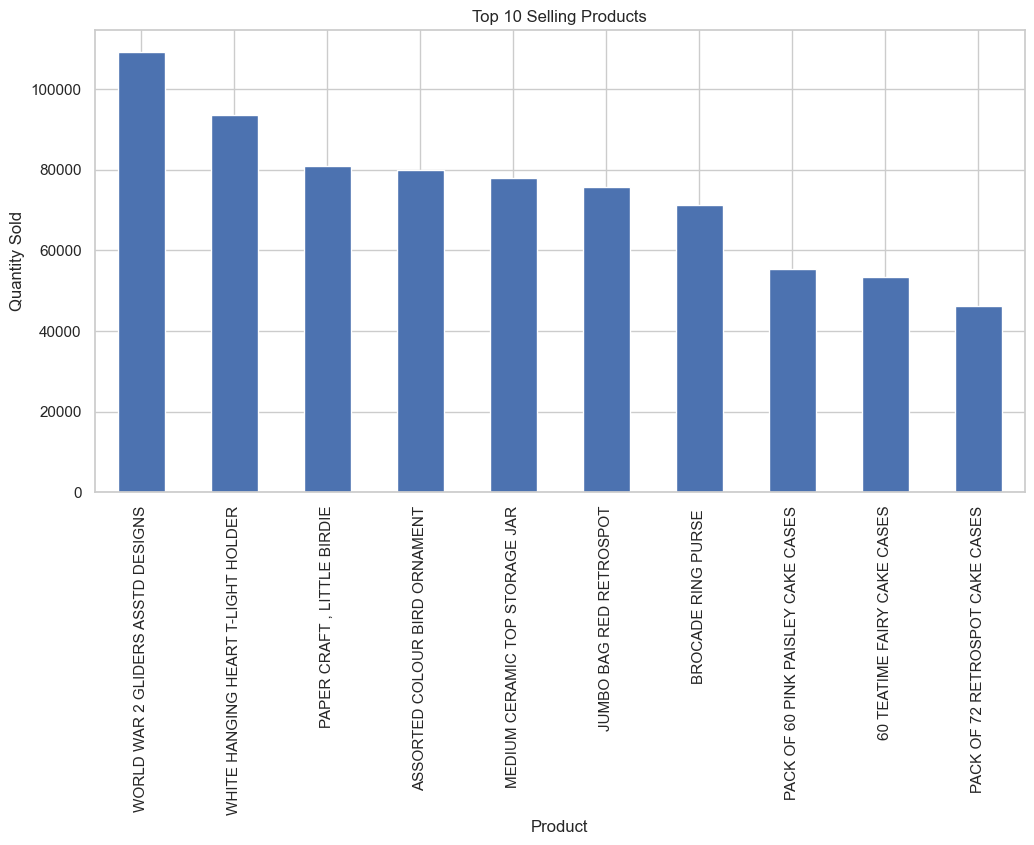

In [8]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=90)

plt.show()

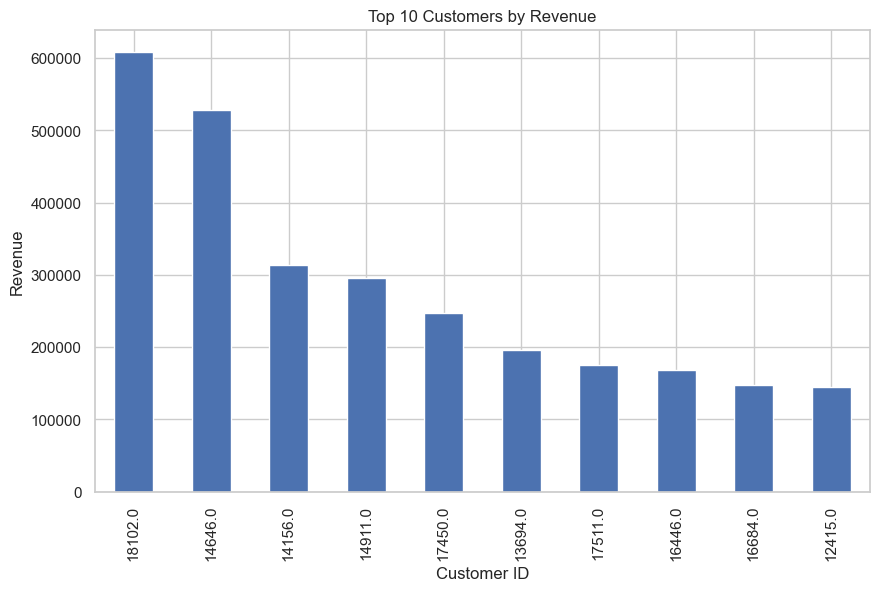

In [9]:
top_customers = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")

plt.show()

In [21]:
# Create a Year-Month column
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

# Calculate monthly revenue
monthly_sales = (
    df.groupby("YearMonth")["Revenue"]
      .sum()
)

# Convert index to string for plotting
monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales

YearMonth
2009-12     686654.160
2010-01     557319.062
2010-02     506371.066
2010-03     699608.991
2010-04     594609.192
2010-05     599985.790
2010-06     639066.580
2010-07     591636.740
2010-08     604242.650
2010-09     831615.001
2010-10    1036680.000
2010-11    1172336.042
2010-12     884591.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518210.790
Name: Revenue, dtype: float64

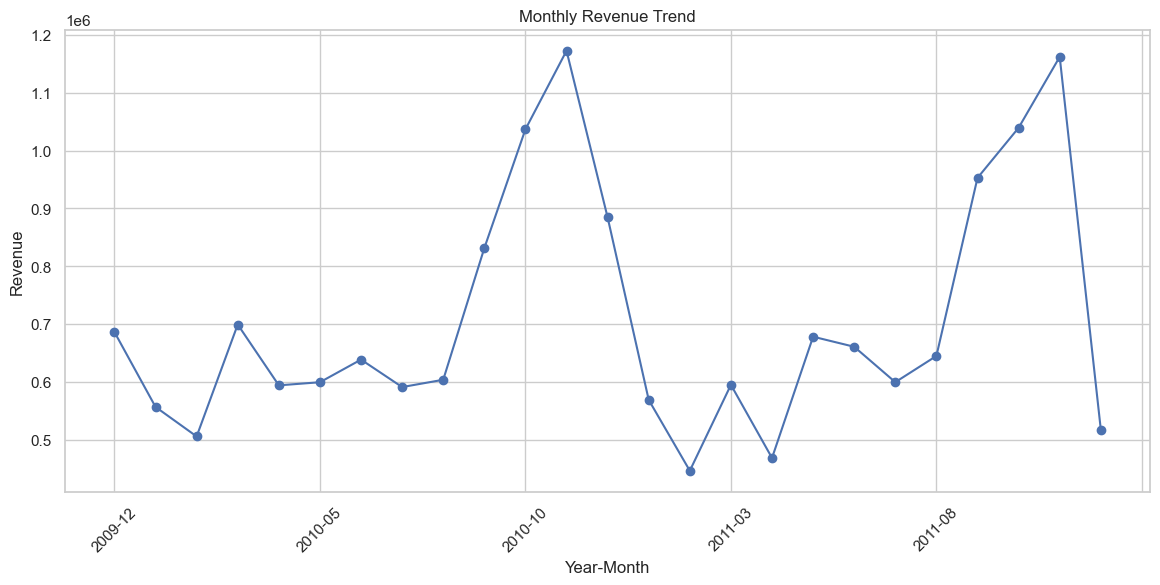

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [12]:
weekday_sales = (
    df.groupby("DayOfWeek")["Revenue"]
      .sum()
)

weekday_sales

DayOfWeek
Friday       2758423.493
Monday       2817407.806
Saturday        9803.050
Sunday       1816413.342
Thursday     3841082.962
Tuesday      3384678.832
Wednesday    3115619.693
Name: Revenue, dtype: float64

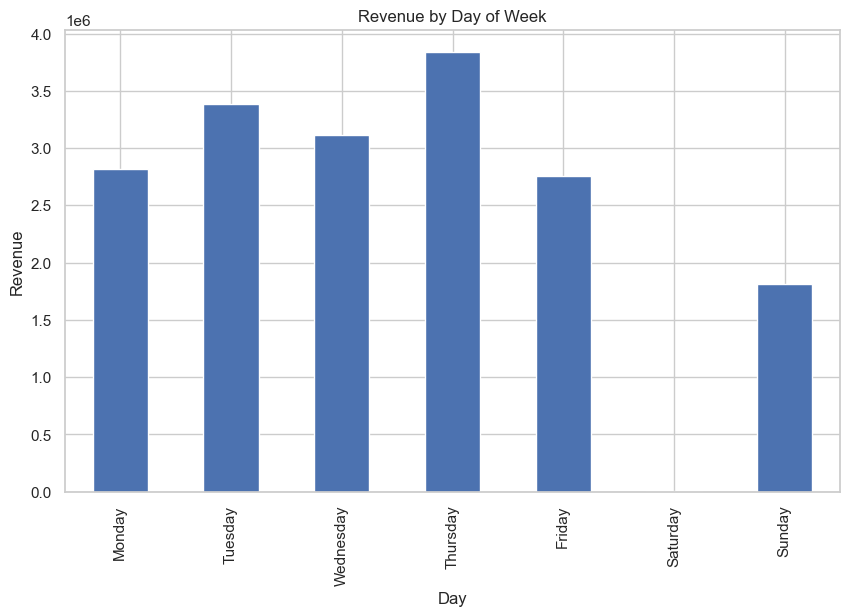

In [13]:
order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = weekday_sales.reindex(order)

plt.figure(figsize=(10,6))

weekday_sales.plot(kind="bar")

plt.title("Revenue by Day of Week")

plt.xlabel("Day")

plt.ylabel("Revenue")

plt.show()

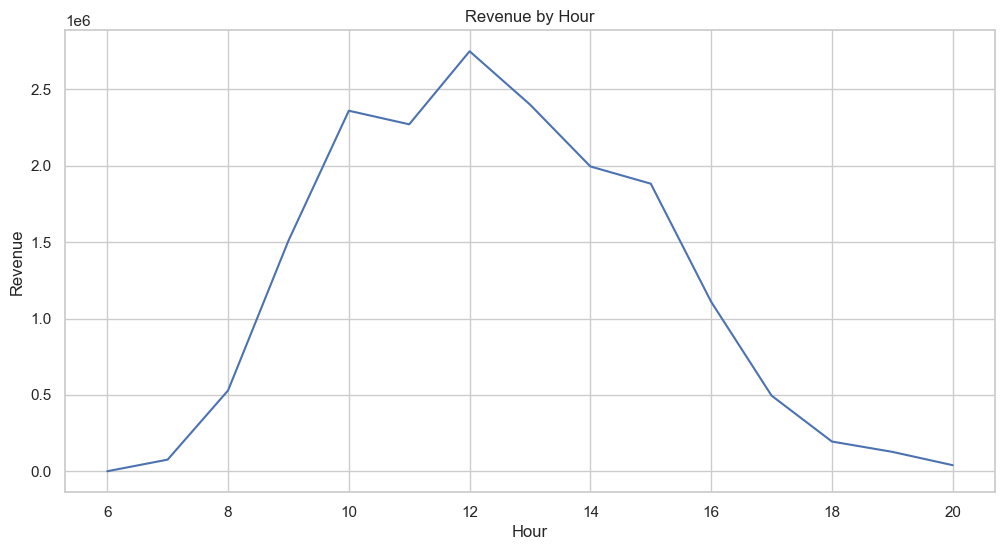

In [14]:
hourly_sales = (
    df.groupby("Hour")["Revenue"]
      .sum()
)

plt.figure(figsize=(12,6))

hourly_sales.plot()

plt.title("Revenue by Hour")

plt.xlabel("Hour")

plt.ylabel("Revenue")

plt.show()

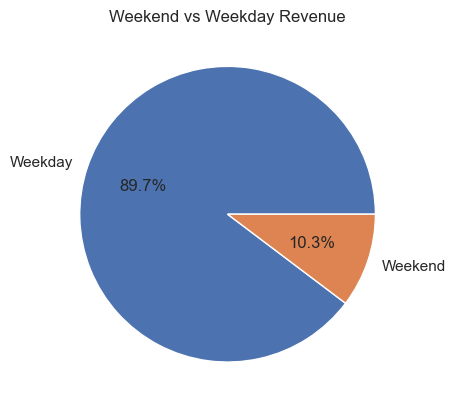

In [15]:
weekend_sales = (
    df.groupby("IsWeekend")["Revenue"]
      .sum()
)

weekend_sales.index = ["Weekday","Weekend"]

weekend_sales.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Weekend vs Weekday Revenue")

plt.show()

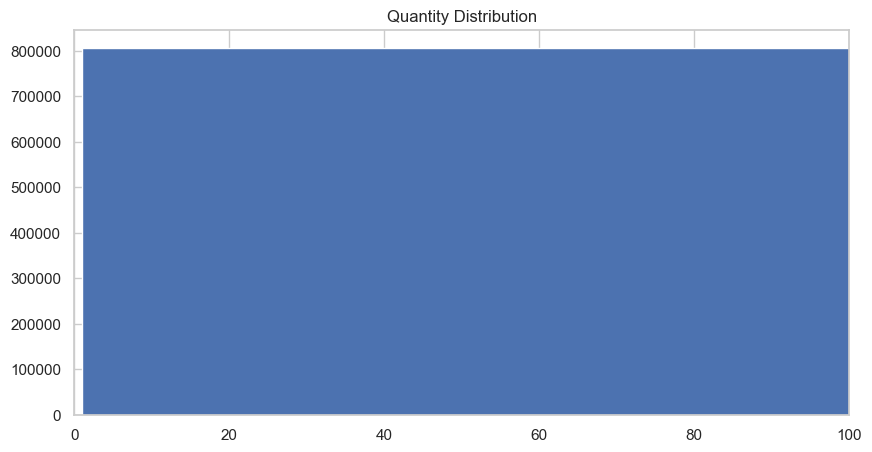

In [16]:
plt.figure(figsize=(10,5))

plt.hist(df["Quantity"], bins=50)

plt.xlim(0,100)

plt.title("Quantity Distribution")

plt.show()

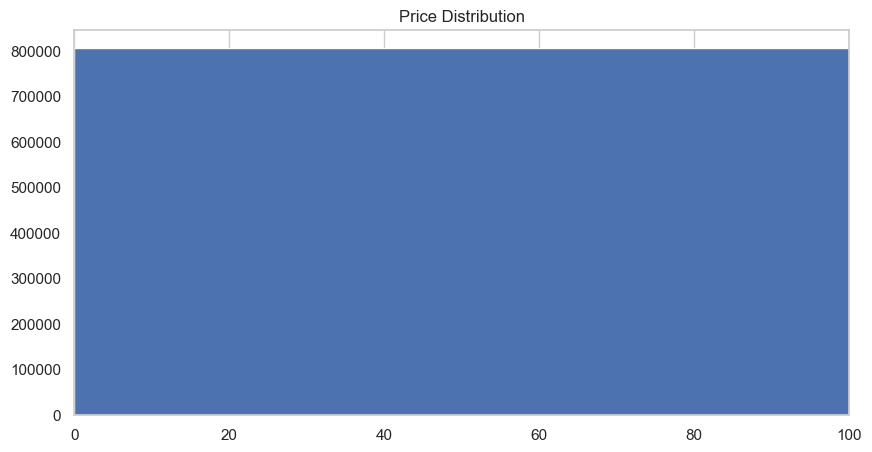

In [17]:
plt.figure(figsize=(10,5))

plt.hist(df["Price"], bins=50)

plt.xlim(0,100)

plt.title("Price Distribution")

plt.show()

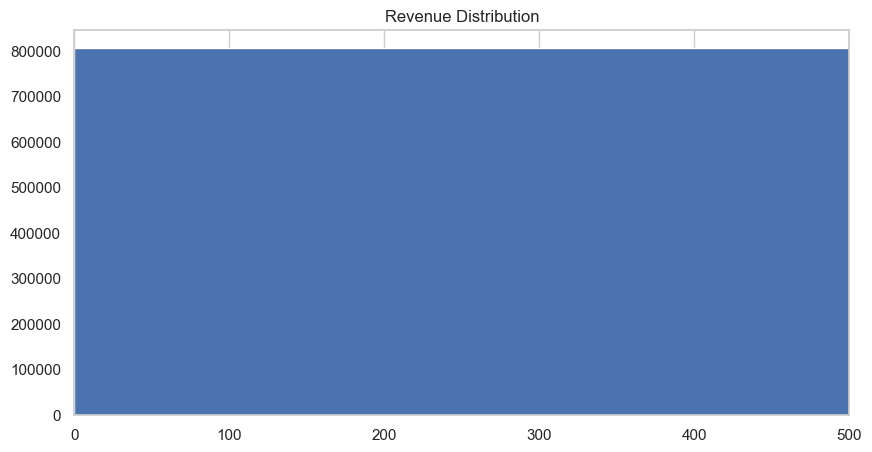

In [18]:
plt.figure(figsize=(10,5))

plt.hist(df["Revenue"], bins=50)

plt.xlim(0,500)

plt.title("Revenue Distribution")

plt.show()

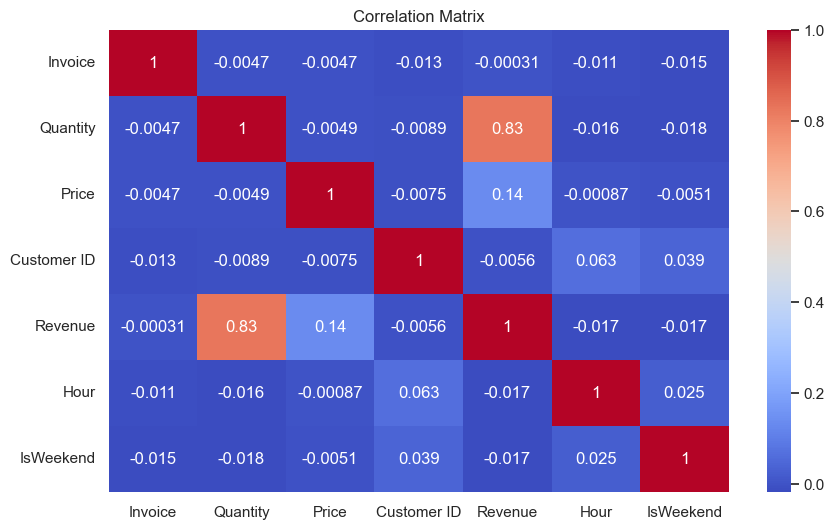

In [19]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [20]:
print("EDA Completed Successfully ✅")
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

EDA Completed Successfully ✅
Rows : 805549
Columns : 13
